<a href="https://colab.research.google.com/github/brimas3/DATA342-Lab-1/blob/main/DATA342_Lab_2_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 1

In [1]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install Required Libraries

!pip install openpyxl matplotlib pandas

In [3]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load Excel File

import requests
import pandas as pd

file_id = '14detpDac5-JgJ4prGiXZ2UEJQM3UmzGUnJLZ-ERWT64'
url = f'https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx'
response = requests.get(url)

if response.status_code == 200:
    with open('DATA342 Lab 1 Data (Netflix vs. Disney).xlsx', 'wb') as f:
        f.write(response.content)
    df = pd.read_excel('DATA342 Lab 1 Data (Netflix vs. Disney).xlsx', sheet_name='Daily Returns 2024', engine='openpyxl')
else:
    print(f"Error downloading file: {response.status_code}")


In [5]:
# Display Sample Rows

print(df.head())

        Date Ticker  Adj Close  Daily Return
0 2024-01-02   NFLX     468.50           NaN
1 2024-01-03   NFLX     470.26      0.003757
2 2024-01-04   NFLX     474.67      0.009378
3 2024-01-05   NFLX     474.06     -0.001285
4 2024-01-08   NFLX     485.03      0.023141


In [6]:
# Clean and Format the Data

df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Daily Return'])

In [7]:
# Seperate Data

nflx_df = df[df['Ticker'] == 'NFLX'].copy()
dis_df = df[df['Ticker'] == 'DIS'].copy()

In [8]:
# Display Sample Rows

print("\nNetflix Daily Returns:")
print(nflx_df[['Date', 'Adj Close', 'Daily Return']].head())

print("\nDIS Daily Returns:")
print(dis_df[['Date', 'Adj Close', 'Daily Return']].head())


Netflix Daily Returns:
        Date  Adj Close  Daily Return
1 2024-01-03     470.26      0.003757
2 2024-01-04     474.67      0.009378
3 2024-01-05     474.06     -0.001285
4 2024-01-08     485.03      0.023141
5 2024-01-09     482.09     -0.006061

DIS Daily Returns:
          Date  Adj Close  Daily Return
251 2024-01-03      90.44     -0.899559
252 2024-01-04      89.37     -0.011831
253 2024-01-05      89.70      0.003693
254 2024-01-08      90.34      0.007135
255 2024-01-09      88.49     -0.020478


/tmp/ipython-input-2952745585.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([nflx_df['Daily Return'], dis_df['Daily Return']], labels=['NFLX', 'DIS'])


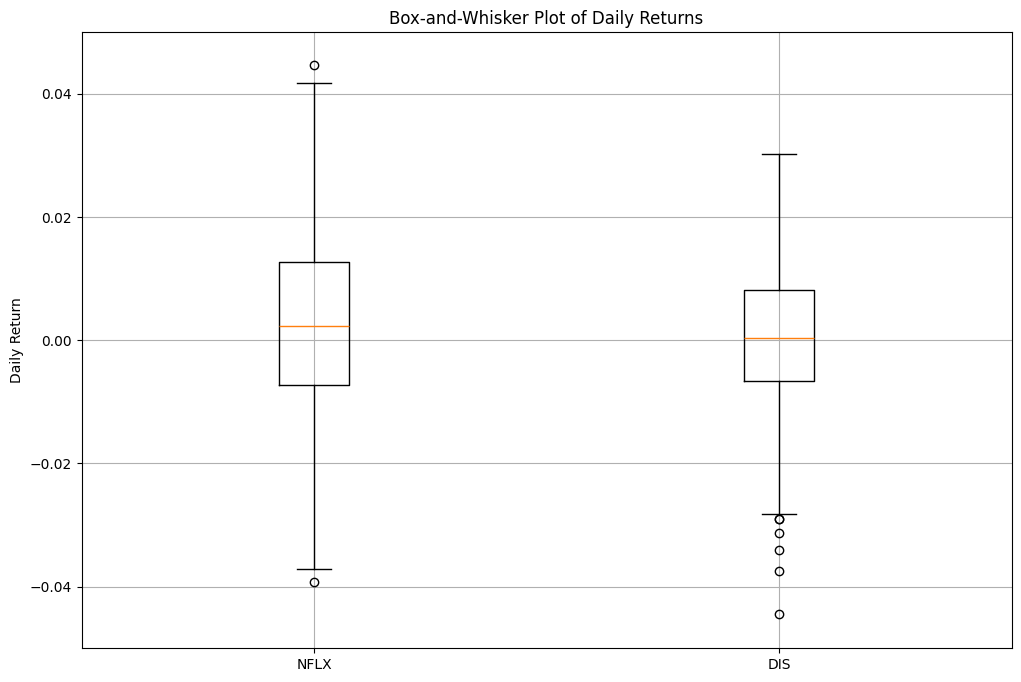

In [9]:
plt.figure(figsize=(12, 8))
plt.boxplot([nflx_df['Daily Return'], dis_df['Daily Return']], labels=['NFLX', 'DIS'])
plt.title('Box-and-Whisker Plot of Daily Returns')
plt.ylabel('Daily Return')
plt.ylim(-0.05, 0.05)
plt.grid(True)
plt.show()

Lab 2

In [10]:
from scipy import stats

def descriptive_stats(series):
    return {
        'Mean': series.mean(),
        'Median': series.median(),
        'Mode': series.mode().iloc[0] if not series.mode().empty else None,
        'Standard Deviation': series.std(),
        'Sample Variance': series.var(),
        'Kurtosis': series.kurtosis(),
        'Skewness': series.skew(),
        'Range': series.max() - series.min(),
        'Minimum': series.min(),
        'Maximum': series.max()
    }

# Compute descriptive statistics
nflx_stats = descriptive_stats(nflx_df['Daily Return'])
dis_stats = descriptive_stats(dis_df['Daily Return'])

print("Descriptive Statistics for Netflix (NFLX):")
for key, value in nflx_stats.items():
    print(f"{key}: {value}")

print("\nDescriptive Statistics for Disney (DIS):")
for key, value in dis_stats.items():
    print(f"{key}: {value}")

Descriptive Statistics for Netflix (NFLX):
Mean: 0.00278715185474652
Median: 0.002366699398
Mode: -0.09093291405
Standard Deviation: 0.018608014213506604
Sample Variance: 0.00034625819297006376
Kurtosis: 9.616669621082504
Skewness: 0.903436269217501
Range: 0.20180326965
Minimum: -0.09093291405
Maximum: 0.1108703556

Descriptive Statistics for Disney (DIS):
Mean: -0.00267101171798368
Median: 0.0003955876007
Mode: -0.8995590995
Standard Deviation: 0.05924366927935541
Sample Variance: 0.0035098123496816406
Kurtosis: 213.166863718388
Skewness: -14.017761271711903
Range: 1.0145544997
Minimum: -0.8995590995
Maximum: 0.1149954002


In [12]:
# Hypothesis Testing: Independent t-test
t_stat, p_value = stats.ttest_ind(nflx_df['Daily Return'], dis_df['Daily Return'], equal_var=False)
print("\nHypothesis Testing (Independent t-test):")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


Hypothesis Testing (Independent t-test):
T-statistic: 1.3897736264517115
P-value: 0.16563617277941803


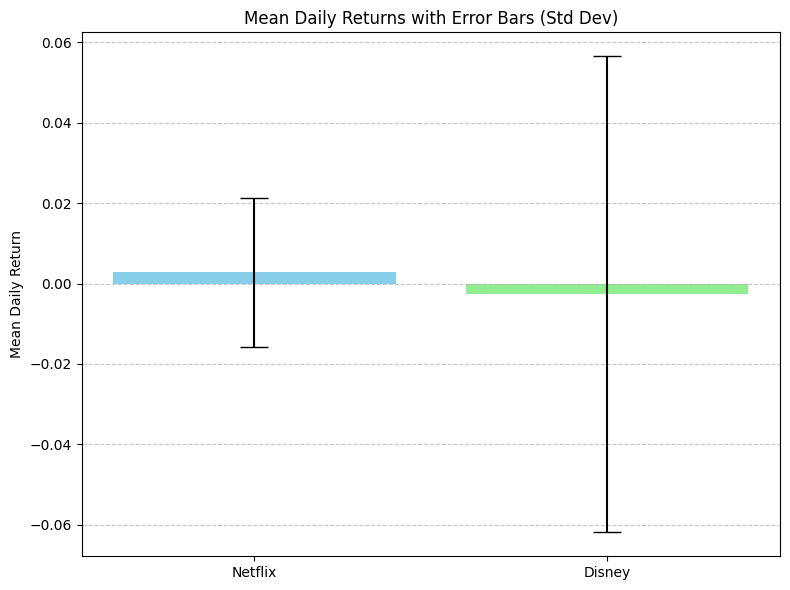

In [13]:
# Install required libraries (if not already installed)
!pip install pandas matplotlib openpyxl scipy

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the Excel file from Google Drive or URL
file_path = '/content/DATA342 Lab 1 Data (Netflix vs. Disney).xlsx'
df = pd.read_excel('DATA342 Lab 1 Data (Netflix vs. Disney).xlsx', sheet_name='Daily Returns 2024', engine='openpyxl')

# Clean and filter the data
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Daily Return'])

# Separate Walmart and Costco data
nflx_df = df[df['Ticker'] == 'NFLX'].copy()
dis_df = df[df['Ticker'] == 'DIS'].copy()

# Compute mean and standard deviation for error bars
mean_nflx = nflx_df['Daily Return'].mean()
std_nflx = nflx_df['Daily Return'].std()
mean_dis = dis_df['Daily Return'].mean()
std_dis = dis_df['Daily Return'].std()

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(nflx_df['Daily Return'], dis_df['Daily Return'], equal_var=False)

# Create bar plot with error bars
means = [mean_nflx, mean_dis]
errors = [std_nflx, std_dis]
labels = ['Netflix', 'Disney']
colors = ['skyblue', 'lightgreen']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, means, yerr=errors, capsize=10, color=colors)

# Add asterisk if p-value < 0.05
if p_value < 0.05:
    max_height = max(means)
    y = max_height + max(errors) + 0.005
    plt.plot([0, 1], [y, y], color='black')
    plt.text(0.5, y + 0.002, '*', ha='center', va='bottom', fontsize=20)

# Customize plot
plt.title('Mean Daily Returns with Error Bars (Std Dev)')
plt.ylabel('Mean Daily Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()